In [ ]:
# Run this first. Colab may restart after installation — that is normal.
# After restart, skip this cell and run from Cell 2.

!pip install shap xgboost scikit-learn pandas numpy matplotlib seaborn -q
print('All libraries installed successfully!')

All libraries installed successfully!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score)
import shap

print('All imports successful!')
shap.initjs()  # Initialize SHAP JavaScript visualizations

All imports successful!


In [ ]:
# NSL-KDD column names (41 features + label + difficulty)
col_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
    'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

# Load directly from URL (no manual download needed)
train_url = 'https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B_20Percent.txt'
test_url  = 'https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTest%2B.txt'

train_df = pd.read_csv(train_url, header=None, names=col_names)
test_df  = pd.read_csv(test_url,  header=None, names=col_names)

# Drop difficulty column (not used as a feature)
train_df.drop('difficulty', axis=1, inplace=True)
test_df.drop('difficulty',  axis=1, inplace=True)

print(f'Training samples : {len(train_df)}')
print(f'Test samples     : {len(test_df)}')
print(f'Features         : {train_df.shape[1] - 1}')
print('\nClass distribution in training set:')
print(train_df['label'].value_counts())

Training samples : 25192
Test samples     : 22544
Features         : 41

Class distribution in training set:
label
normal             13449
neptune             8282
ipsweep              710
satan                691
portsweep            587
smurf                529
nmap                 301
back                 196
teardrop             188
warezclient          181
pod                   38
guess_passwd          10
warezmaster            7
buffer_overflow        6
imap                   5
rootkit                4
phf                    2
multihop               2
ftp_write              1
land                   1
loadmodule             1
spy                    1
Name: count, dtype: int64


In [ ]:
# ── 4a. Map attack types to 5 categories ──────────────────────────────
attack_map = {
    'normal': 'Normal',
    # DoS attacks
    'back':'DoS','land':'DoS','neptune':'DoS','pod':'DoS',
    'smurf':'DoS','teardrop':'DoS','apache2':'DoS','udpstorm':'DoS',
    'processtable':'DoS','worm':'DoS',
    # Probe attacks
    'ipsweep':'Probe','nmap':'Probe','portsweep':'Probe',
    'satan':'Probe','mscan':'Probe','saint':'Probe',
    # R2L attacks
    'ftp_write':'R2L','guess_passwd':'R2L','imap':'R2L','multihop':'R2L',
    'phf':'R2L','spy':'R2L','warezclient':'R2L','warezmaster':'R2L',
    'sendmail':'R2L','named':'R2L','snmpgetattack':'R2L',
    'snmpguess':'R2L','xlock':'R2L','xsnoop':'R2L','httptunnel':'R2L',
    # U2R attacks
    'buffer_overflow':'U2R','loadmodule':'U2R','perl':'U2R',
    'rootkit':'U2R','sqlattack':'U2R','xterm':'U2R','ps':'U2R',
}

train_df['attack_cat'] = train_df['label'].map(attack_map).fillna('Unknown')
test_df['attack_cat']  = test_df['label'].map(attack_map).fillna('Unknown')

# ── 4b. Encode categorical features ───────────────────────────────────
cat_cols = ['protocol_type', 'service', 'flag']
le = LabelEncoder()

for col in cat_cols:
    combined = pd.concat([train_df[col], test_df[col]])
    le.fit(combined)
    train_df[col] = le.transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])

# ── 4c. Encode target label ────────────────────────────────────────────
label_enc = LabelEncoder()
all_labels = pd.concat([train_df['attack_cat'], test_df['attack_cat']])
label_enc.fit(all_labels)

train_df['target'] = label_enc.transform(train_df['attack_cat'])
test_df['target']  = label_enc.transform(test_df['attack_cat'])

print('Class mapping:')
for i, cls in enumerate(label_enc.classes_):
    print(f'  {i} -> {cls}')

# ── 4d. Prepare feature matrices ──────────────────────────────────────
feature_cols = [c for c in train_df.columns
                if c not in ['label', 'attack_cat', 'target']]

X_train = train_df[feature_cols]
y_train = train_df['target']
X_test  = test_df[feature_cols]
y_test  = test_df['target']

# ── 4e. Scale features ─────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

X_train_sc = pd.DataFrame(X_train_sc, columns=feature_cols)
X_test_sc  = pd.DataFrame(X_test_sc,  columns=feature_cols)

print(f'\nFeature matrix shape: {X_train_sc.shape}')
print('Preprocessing complete!')

Class mapping:
  0 -> DoS
  1 -> Normal
  2 -> Probe
  3 -> R2L
  4 -> U2R
  5 -> Unknown

Feature matrix shape: (25192, 41)
Preprocessing complete!


In [ ]:
# ── Decision Tree ─────────────────────────────────────────────────────
print('Training Decision Tree...')
dt = DecisionTreeClassifier(max_depth=20, random_state=42)
dt.fit(X_train_sc, y_train)
dt_pred = dt.predict(X_test_sc)
dt_acc  = accuracy_score(y_test, dt_pred)
print(f'Decision Tree Accuracy: {dt_acc:.4f}')

# ── Random Forest ─────────────────────────────────────────────────────
print('\nTraining Random Forest (this takes ~1-2 minutes)...')
rf = RandomForestClassifier(n_estimators=100, max_depth=20,
                            random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)
rf_pred = rf.predict(X_test_sc)
rf_acc  = accuracy_score(y_test, rf_pred)
print(f'Random Forest Accuracy: {rf_acc:.4f}')

# ── XGBoost ────────────────────────────────────────────────────────────
print('\nTraining XGBoost (this takes ~1-2 minutes)...')
xgb = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                    use_label_encoder=False, eval_metric='mlogloss',
                    random_state=42, n_jobs=-1)
xgb.fit(X_train_sc, y_train)
xgb_pred = xgb.predict(X_test_sc)
xgb_acc  = accuracy_score(y_test, xgb_pred)
print(f'XGBoost Accuracy      : {xgb_acc:.4f}')

print('\n=== All models trained ===')

Training Decision Tree...
Decision Tree Accuracy: 0.7498

Training Random Forest (this takes ~1-2 minutes)...
Random Forest Accuracy: 0.7665

Training XGBoost (this takes ~1-2 minutes)...
XGBoost Accuracy      : 0.7645

=== All models trained ===



 Decision Tree — Classification Report
              precision    recall  f1-score   support

         DoS       0.96      0.80      0.87      7167
      Normal       0.67      0.97      0.79      9711
       Probe       0.71      0.62      0.66      2421
         R2L       0.94      0.09      0.17      2885
         U2R       0.55      0.18      0.27        67
     Unknown       0.00      0.00      0.00       293

    accuracy                           0.75     22544
   macro avg       0.64      0.44      0.46     22544
weighted avg       0.79      0.75      0.71     22544


 Random Forest — Classification Report
              precision    recall  f1-score   support

         DoS       0.96      0.86      0.91      7167
      Normal       0.66      0.97      0.79      9711
       Probe       0.86      0.63      0.73      2421
         R2L       1.00      0.04      0.08      2885
         U2R       1.00      0.03      0.06        67
     Unknown       0.00      0.00      0.00       29

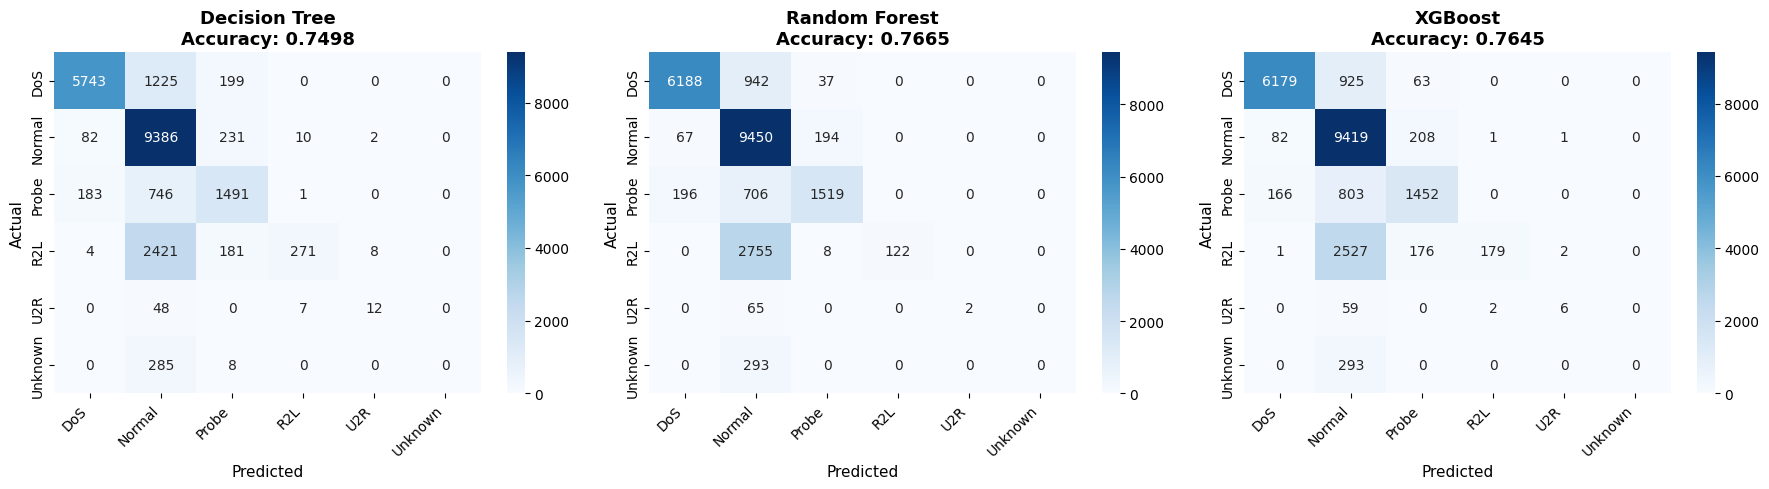

Figure saved as confusion_matrices.png


In [ ]:
class_names = label_enc.classes_

def evaluate_model(name, y_true, y_pred):
    print(f'\n{"="*60}')
    print(f' {name} — Classification Report')
    print(f'{"="*60}')
    print(classification_report(y_true, y_pred, target_names=class_names))

evaluate_model('Decision Tree', y_test, dt_pred)
evaluate_model('Random Forest', y_test, rf_pred)
evaluate_model('XGBoost',       y_test, xgb_pred)

# ── Confusion matrices ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_info = [
    ('Decision Tree', dt_pred),
    ('Random Forest', rf_pred),
    ('XGBoost',       xgb_pred),
]

for ax, (name, pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, pred):.4f}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as confusion_matrices.png')

               Accuracy  Precision  Recall  F1-Score
Decision Tree    0.7498     0.7877  0.7498    0.7098
Random Forest    0.7665     0.8151  0.7665    0.7179
XGBoost          0.7645     0.8048  0.7645    0.7184


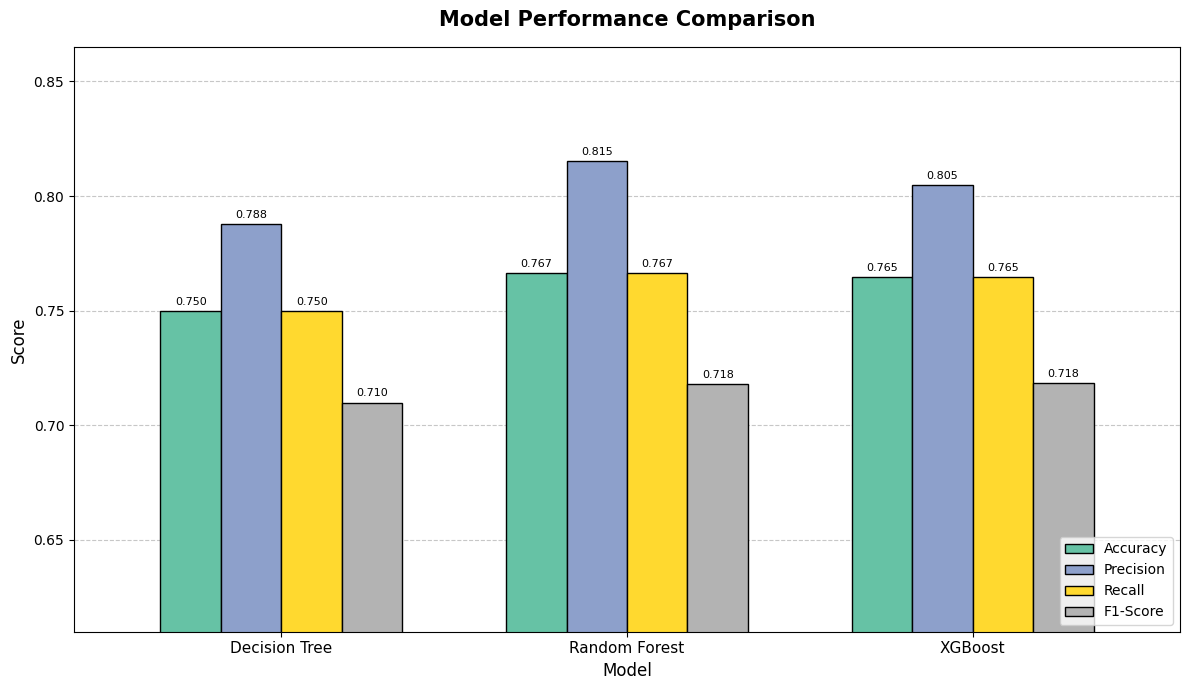

Saved: model_comparison.png

Y-axis range: 0.61 — 0.87

Actual scores:
               Accuracy  Precision  Recall  F1-Score
Decision Tree    0.7498     0.7877  0.7498    0.7098
Random Forest    0.7665     0.8151  0.7665    0.7179
XGBoost          0.7645     0.8048  0.7645    0.7184


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = {}
for name, pred in [('Decision Tree', dt_pred),
                   ('Random Forest', rf_pred),
                   ('XGBoost',       xgb_pred)]:
    metrics[name] = {
        'Accuracy' : accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, average='weighted', zero_division=0),
        'Recall'   : recall_score(y_test, pred, average='weighted', zero_division=0),
        'F1-Score' : f1_score(y_test, pred, average='weighted', zero_division=0),
    }

metrics_df = pd.DataFrame(metrics).T
print(metrics_df.round(4))

# ── Auto-scale y-axis ──────────────────────────────────────────────────
min_val = metrics_df.values.min()
max_val = metrics_df.values.max()
y_floor = max(0.0, min_val - 0.10)   # 10% below lowest score, never below 0
y_ceil  = min(1.0, max_val + 0.05)   # 5% above highest score

# ── Plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
metrics_df.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black', width=0.7)

ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(y_floor, y_ceil)
ax.legend(loc='lower right', fontsize=10)
ax.set_xticklabels(metrics_df.index, rotation=0, fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

# Add value labels on top of every bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')
print(f'\nY-axis range: {y_floor:.2f} — {y_ceil:.2f}')
print('\nActual scores:')
print(metrics_df.round(4))

Computing SHAP values — this takes 2-3 minutes...
Raw shape: (500, 41, 5)
After transpose: (5, 500, 41)
Classes detected: 5
Class names     : ['DoS', 'Normal', 'Probe', 'R2L', 'U2R', 'Unknown']


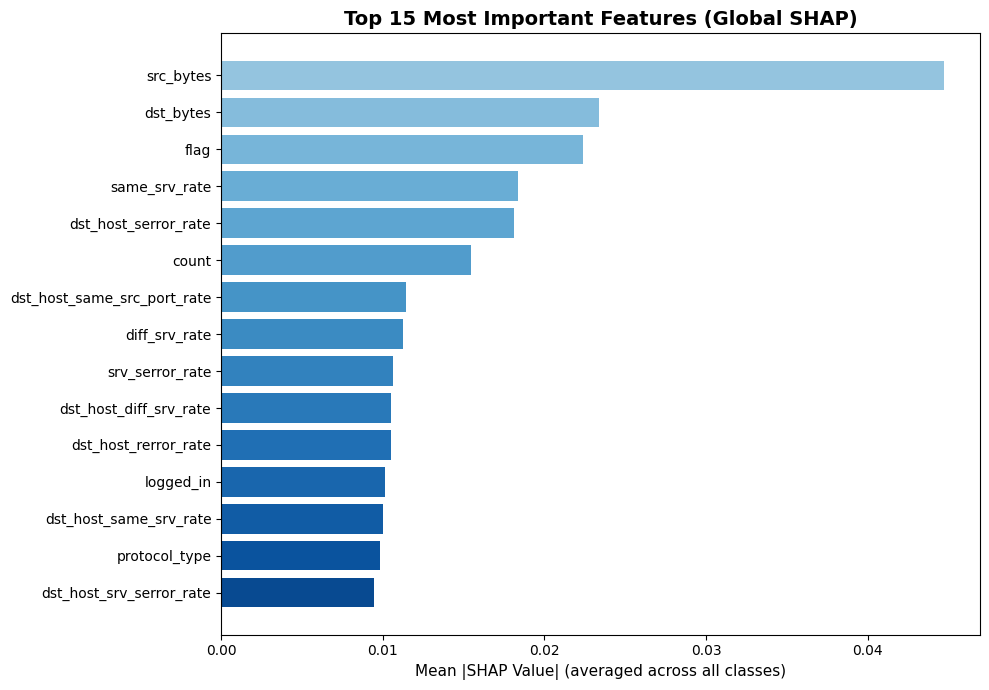

Saved: shap_global_importance.png


In [ ]:
print('Computing SHAP values — this takes 2-3 minutes...')

sample_size = 500
X_sample = X_test_sc.sample(n=sample_size, random_state=42)
y_sample  = y_test.iloc[X_sample.index].reset_index(drop=True)
X_sample  = X_sample.reset_index(drop=True)

explainer   = shap.TreeExplainer(rf)
shap_raw    = explainer.shap_values(X_sample)

# shap_raw shape: (n_samples, n_features, n_classes) = (500, 41, 5)
sv = np.array(shap_raw)
print(f'Raw shape: {sv.shape}')   # expect (500, 41, 5)

# Transpose to (n_classes, n_samples, n_features)
sv = sv.transpose(2, 0, 1)
print(f'After transpose: {sv.shape}')   # expect (5, 500, 41)

n_classes_actual = sv.shape[0]
print(f'Classes detected: {n_classes_actual}')
print(f'Class names     : {list(class_names)}')

# ── Global bar chart ───────────────────────────────────────────────────
mean_per_feature = np.abs(sv).mean(axis=(0, 1))   # (n_features,)
top_n    = 15
top_idx  = np.argsort(mean_per_feature)[::-1][:top_n]
top_feats = [feature_cols[i] for i in top_idx]
top_vals  = mean_per_feature[top_idx]

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, top_n))
ax.barh(np.arange(top_n), top_vals, color=colors)
ax.set_yticks(np.arange(top_n))
ax.set_yticklabels(top_feats, fontsize=10)
ax.set_xlabel('Mean |SHAP Value| (averaged across all classes)', fontsize=11)
ax.set_title('Top 15 Most Important Features (Global SHAP)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_global_importance.png')

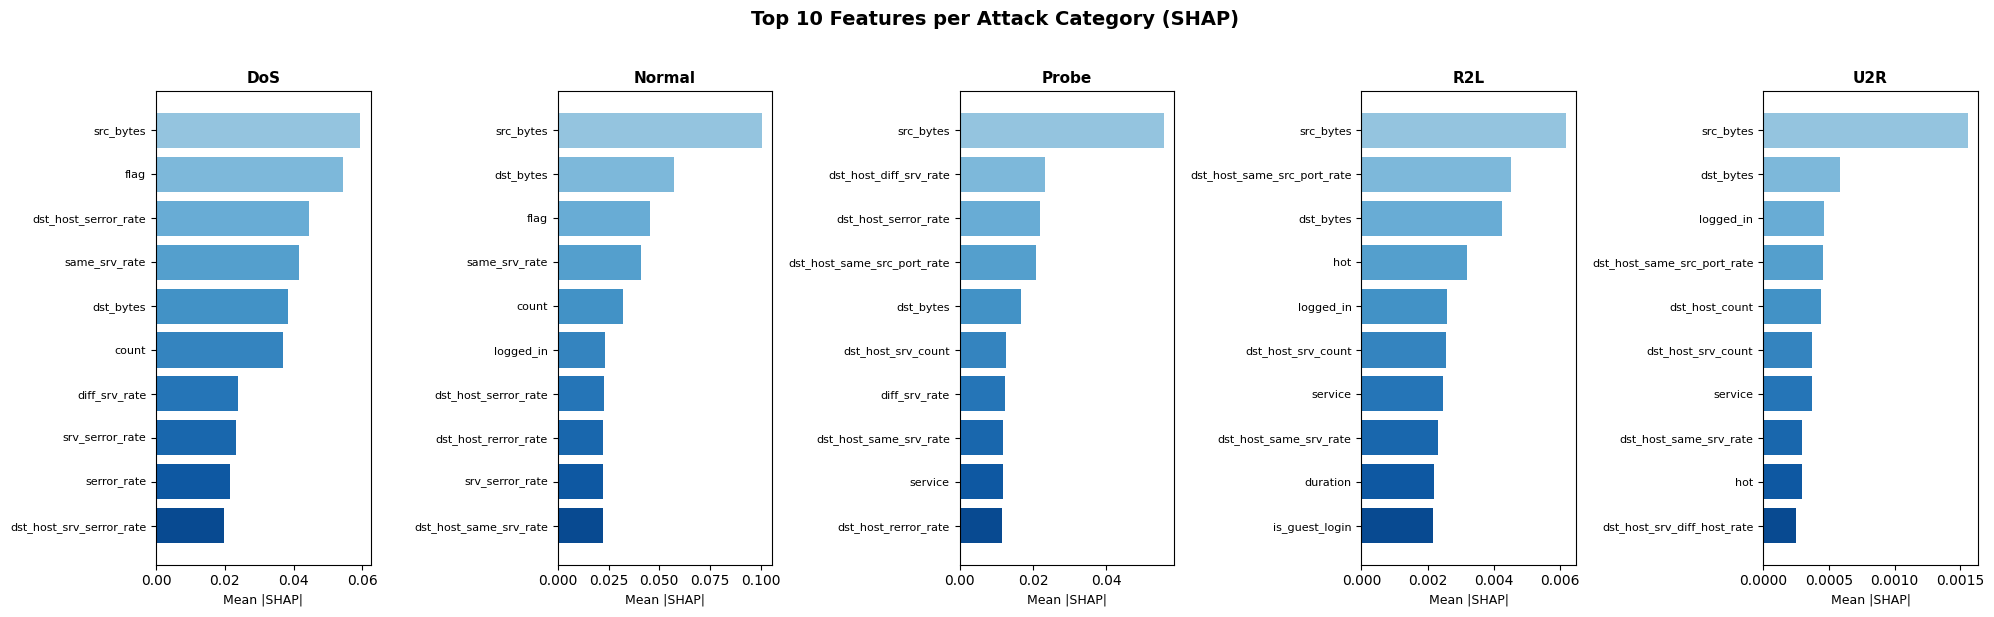

Saved: shap_per_class.png


In [ ]:
# sv shape: (n_classes, n_samples, n_features) from Cell 8
n_cls = sv.shape[0]
fig, axes = plt.subplots(1, n_cls, figsize=(4 * n_cls, 6))

for i, (cls_name, ax) in enumerate(zip(class_names, axes)):
    mean_shap = np.abs(sv[i]).mean(axis=0)    # (n_features,)
    top_idx   = np.argsort(mean_shap)[::-1][:10]
    top_feats = [feature_cols[j] for j in top_idx]
    top_vals  = mean_shap[top_idx]

    colors = plt.cm.Blues(np.linspace(0.4, 0.9, 10))
    ax.barh(np.arange(10), top_vals, color=colors)
    ax.set_yticks(np.arange(10))
    ax.set_yticklabels(top_feats, fontsize=8)
    ax.set_title(cls_name, fontweight='bold', fontsize=11)
    ax.set_xlabel('Mean |SHAP|', fontsize=9)
    ax.invert_yaxis()

plt.suptitle('Top 10 Features per Attack Category (SHAP)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('shap_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_per_class.png')


--- Local Explanation for: DoS ---
Predicted: DoS


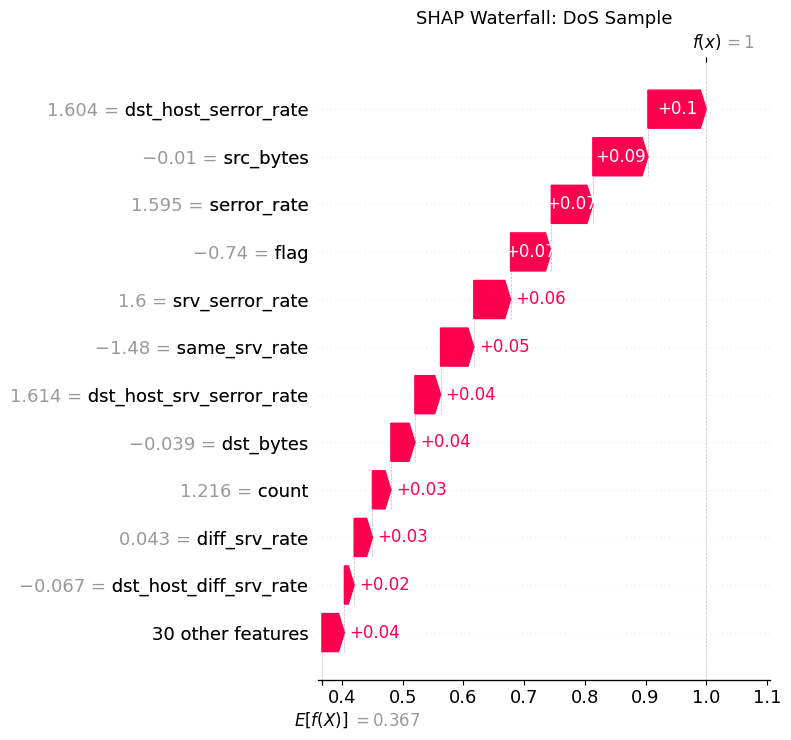

Saved: shap_waterfall_DoS.png

--- Local Explanation for: Normal ---
Predicted: Normal


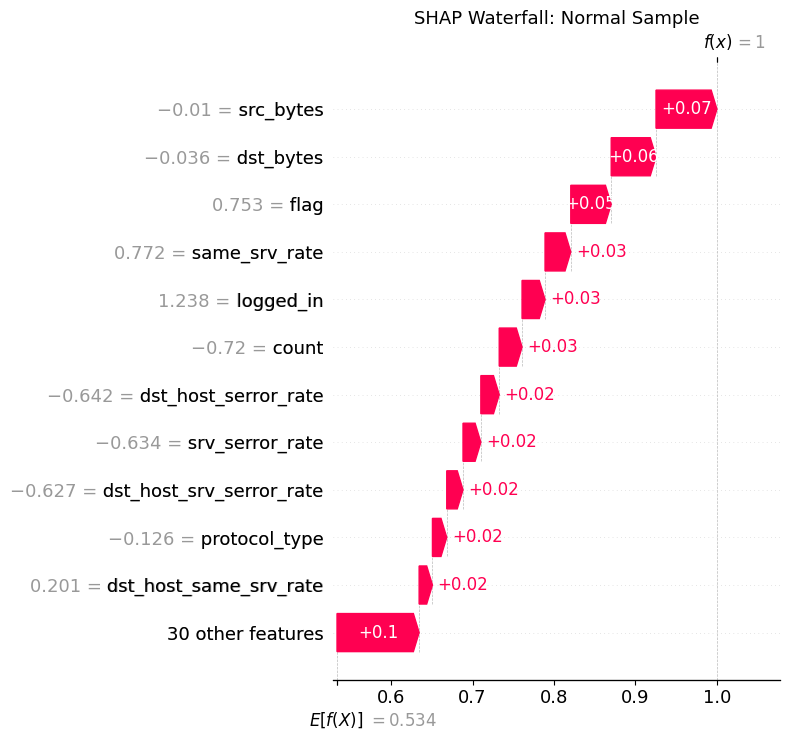

Saved: shap_waterfall_Normal.png

--- Local Explanation for: Probe ---
Predicted: Probe


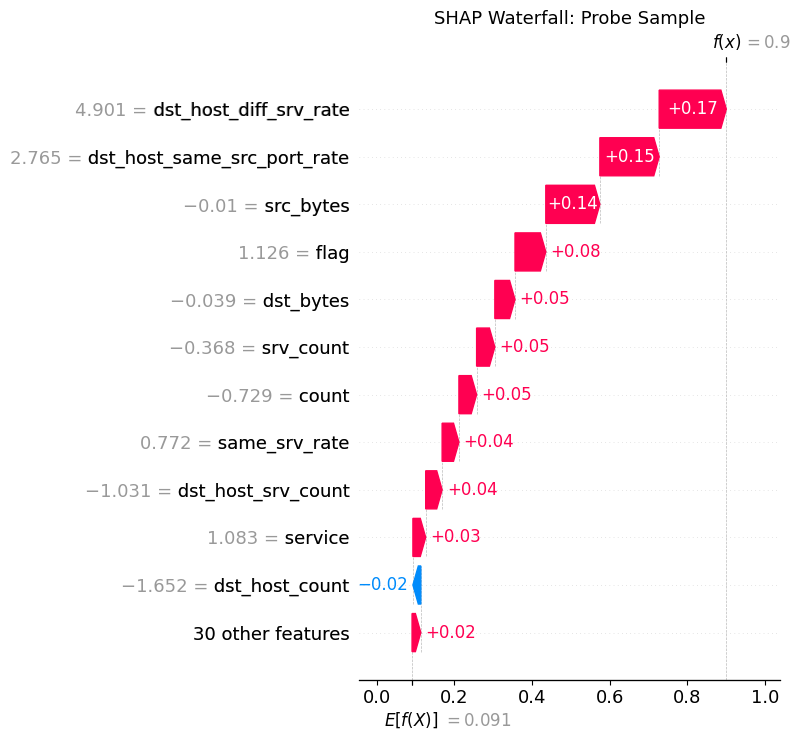

Saved: shap_waterfall_Probe.png

--- Local Explanation for: R2L ---
Predicted: R2L


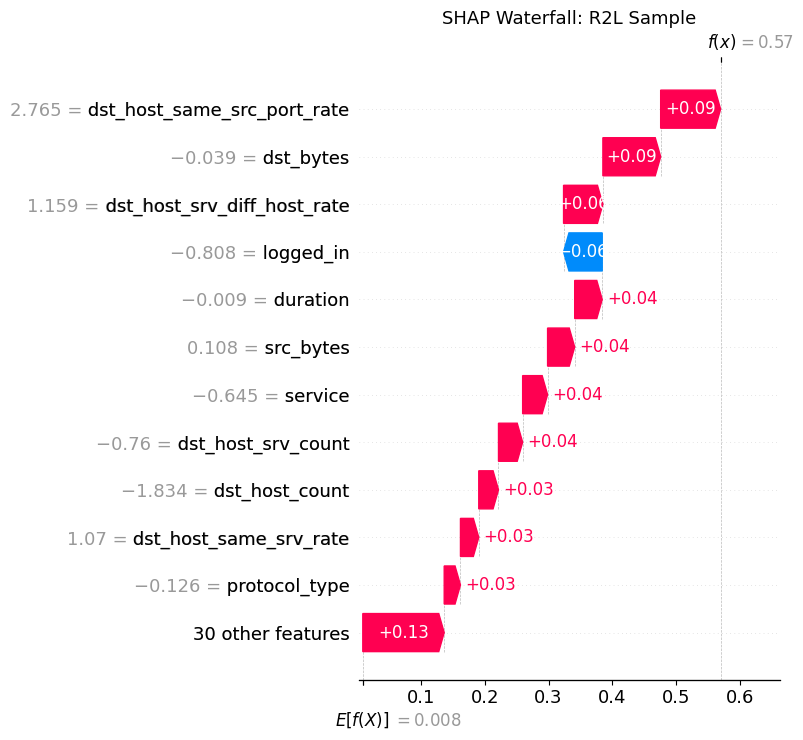

Saved: shap_waterfall_R2L.png
No "U2R" samples in the 500-sample set, skipping.
Skipping "Unknown" — not in SHAP output (index 5 >= 5)

=== All SHAP analyses complete! ===
Find all saved figures in the Colab files panel (left sidebar).


In [ ]:
# sv shape: (n_classes, n_samples, n_features) from Cell 8
exp_val   = explainer.expected_value
n_shap_classes = sv.shape[0]   # 5 — the actual number of SHAP output classes

for target_class_idx, cls_name in enumerate(class_names):

    # Skip if this class index is outside SHAP output range
    if target_class_idx >= n_shap_classes:
        print(f'Skipping "{cls_name}" — not in SHAP output (index {target_class_idx} >= {n_shap_classes})')
        continue

    # Skip if no samples of this class exist in our 500-sample set
    idx = np.where(y_sample.values == target_class_idx)[0]
    if len(idx) == 0:
        print(f'No "{cls_name}" samples in the 500-sample set, skipping.')
        continue

    sample_idx = idx[0]
    print(f'\n--- Local Explanation for: {cls_name} ---')
    pred_class = label_enc.classes_[rf.predict(X_sample.iloc[[sample_idx]])[0]]
    print(f'Predicted: {pred_class}')

    base = exp_val[target_class_idx] if hasattr(exp_val, '__len__') else exp_val

    shap_exp = shap.Explanation(
        values       = sv[target_class_idx][sample_idx],  # (n_features,)
        base_values  = base,
        data         = X_sample.iloc[sample_idx].values,
        feature_names= feature_cols
    )

    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_exp, max_display=12, show=False)
    plt.title(f'SHAP Waterfall: {cls_name} Sample', fontsize=13)
    plt.tight_layout()
    fname = f'shap_waterfall_{cls_name}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

print('\n=== All SHAP analyses complete! ===')
print('Find all saved figures in the Colab files panel (left sidebar).')

In [ ]:
!pip install lime -q
print('LIME installed!')

LIME installed!



--- LIME Explanation for: DoS ---


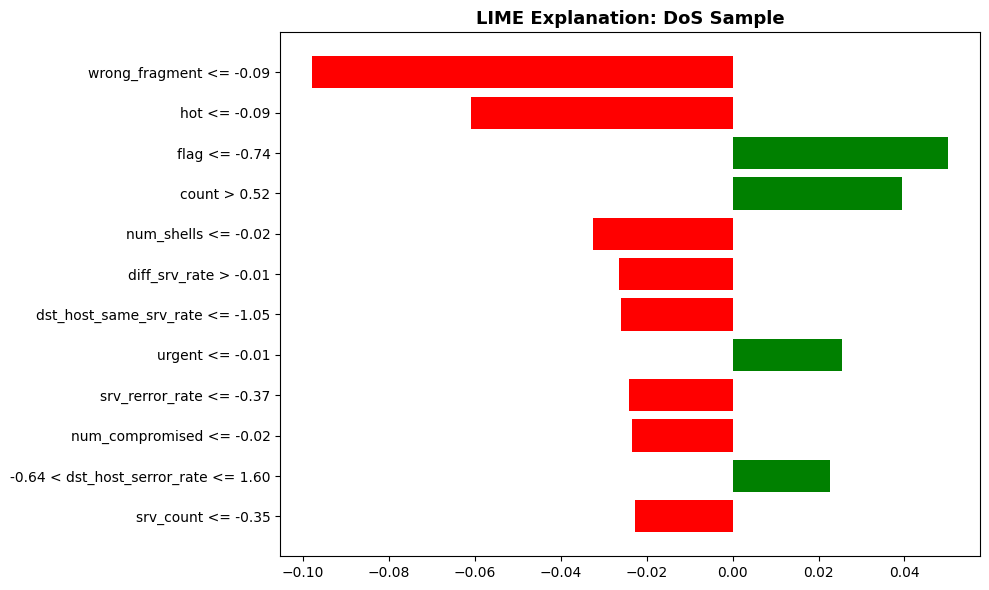

Saved: lime_DoS.png

--- LIME Explanation for: Normal ---


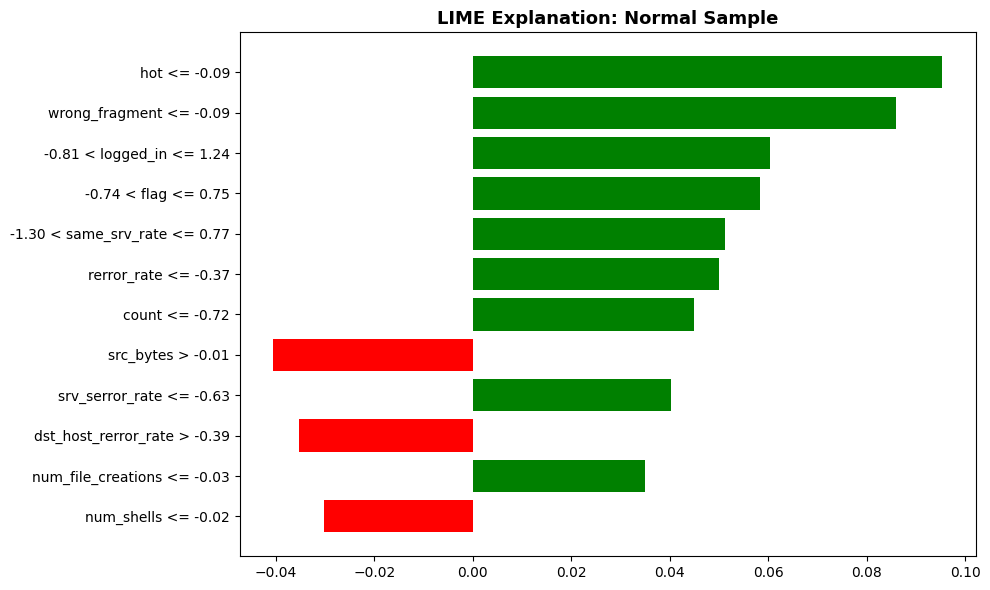

Saved: lime_Normal.png

--- LIME Explanation for: Probe ---


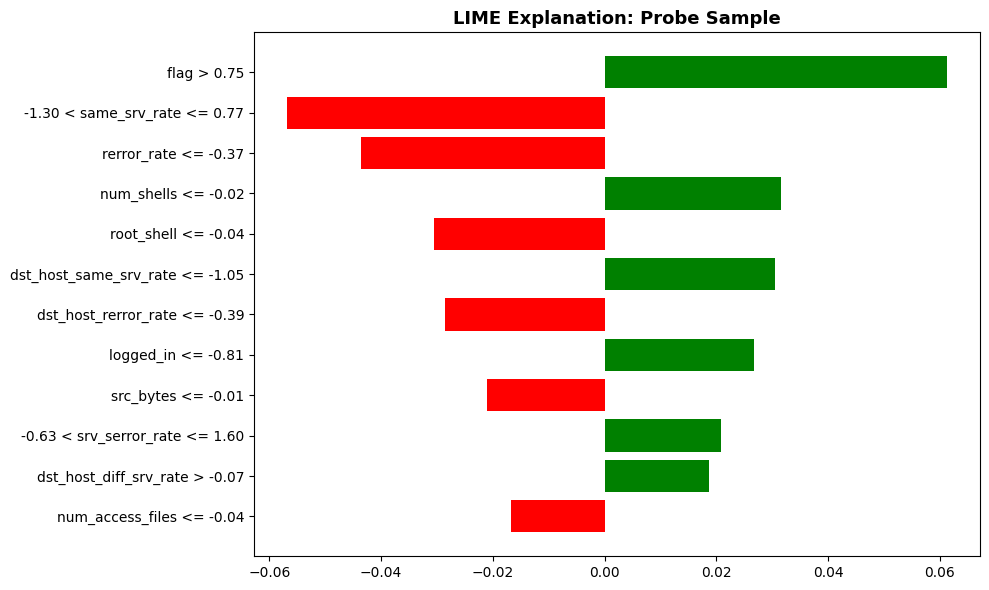

Saved: lime_Probe.png

--- LIME Explanation for: R2L ---


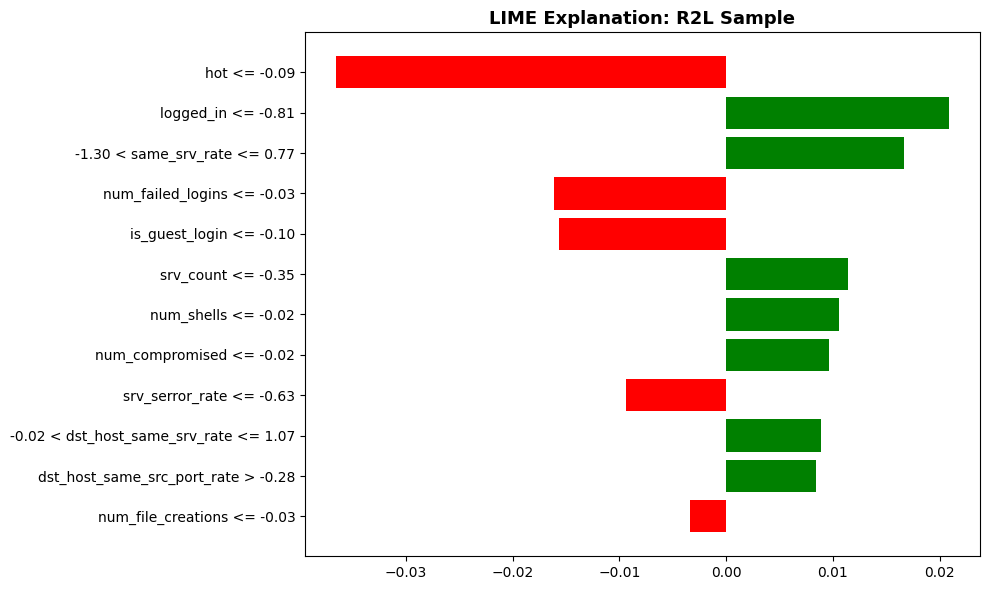

Saved: lime_R2L.png
No "U2R" samples in 500-sample set, skipping.
Skipping "Unknown" — out of range.

=== LIME analysis complete! ===


In [ ]:
from lime.lime_tabular import LimeTabularExplainer

# Create LIME explainer using training data as background
lime_explainer = LimeTabularExplainer(
    training_data  = X_train_sc.values,
    feature_names  = feature_cols,
    class_names    = list(class_names),
    mode           = 'classification',
    random_state   = 42
)

n_shap_classes = sv.shape[0]   # 5 valid classes

for target_class_idx, cls_name in enumerate(class_names):

    # Skip Unknown or out-of-range classes
    if target_class_idx >= n_shap_classes:
        print(f'Skipping "{cls_name}" — out of range.')
        continue

    # Find one sample of this class from X_sample
    idx = np.where(y_sample.values == target_class_idx)[0]
    if len(idx) == 0:
        print(f'No "{cls_name}" samples in 500-sample set, skipping.')
        continue
    sample_idx = idx[0]

    print(f'\n--- LIME Explanation for: {cls_name} ---')

    # Generate LIME explanation for this sample
    lime_exp = lime_explainer.explain_instance(
        data_row       = X_sample.iloc[sample_idx].values,
        predict_fn     = rf.predict_proba,
        num_features   = 12,
        labels         = (target_class_idx,)
    )

    # Plot
    fig = lime_exp.as_pyplot_figure(label=target_class_idx)
    fig.set_size_inches(10, 6)
    plt.title(f'LIME Explanation: {cls_name} Sample', fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = f'lime_{cls_name}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

print('\n=== LIME analysis complete! ===')

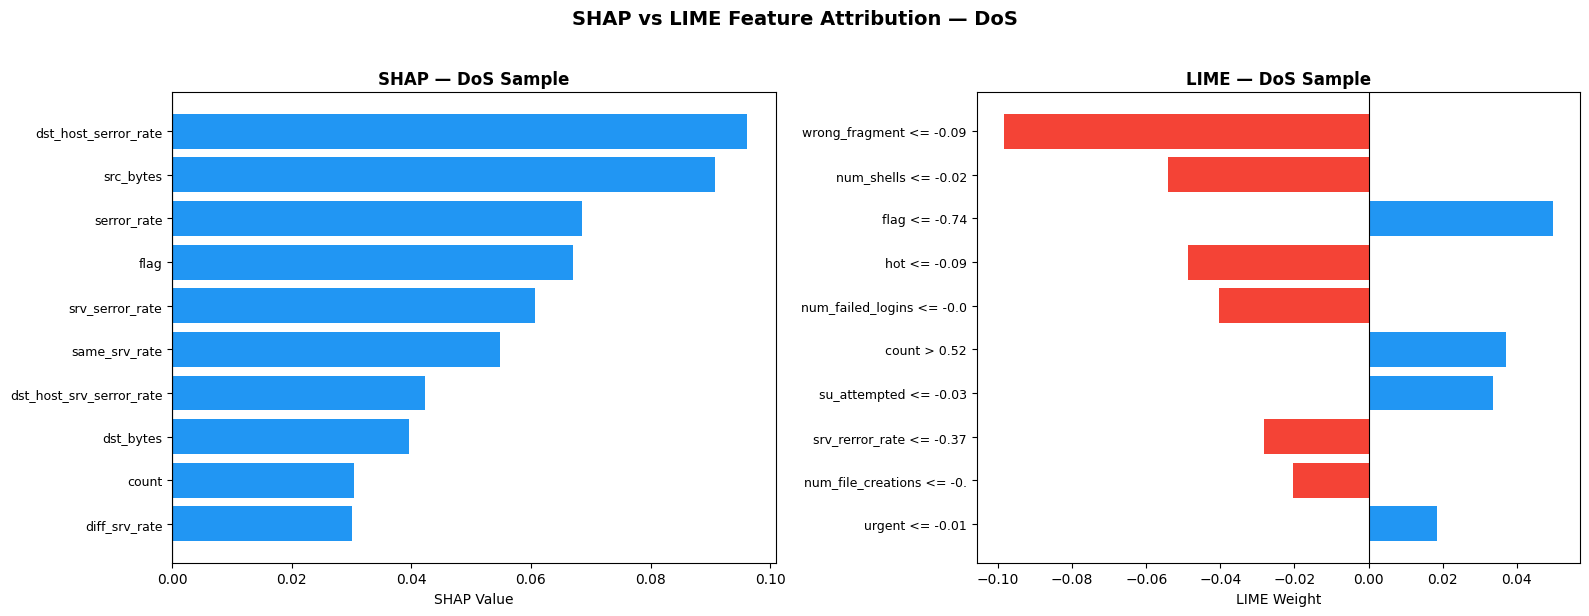

Saved: shap_vs_lime_DoS.png

Blue bars = features pushing TOWARD this class
Red  bars = features pushing AWAY from this class


In [ ]:
target_cls = 'DoS'   # Change to 'Normal', 'Probe', 'R2L' if you prefer
target_idx = list(class_names).index(target_cls)

# Find sample
idx        = np.where(y_sample.values == target_idx)[0][0]

# ── SHAP top features for this sample ─────────────────────────────────
shap_vals_sample = sv[target_idx][idx]   # (n_features,)
shap_top_idx  = np.argsort(np.abs(shap_vals_sample))[::-1][:10]
shap_top_feat = [feature_cols[i] for i in shap_top_idx]
shap_top_val  = shap_vals_sample[shap_top_idx]

# ── LIME top features for this sample ─────────────────────────────────
lime_exp2 = lime_explainer.explain_instance(
    data_row  = X_sample.iloc[idx].values,
    predict_fn= rf.predict_proba,
    num_features=10,
    labels    = (target_idx,)
)
lime_feats_vals = lime_exp2.as_list(label=target_idx)   # list of (feat_str, weight)
lime_feat_names = [x[0][:25] for x in lime_feats_vals]  # truncate long names
lime_feat_vals  = [x[1] for x in lime_feats_vals]

# ── Plot side by side ──────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# SHAP panel
colors_shap = ['#2196F3' if v > 0 else '#F44336' for v in shap_top_val]
ax1.barh(range(len(shap_top_feat)), shap_top_val[::-1], color=colors_shap[::-1])
ax1.set_yticks(range(len(shap_top_feat)))
ax1.set_yticklabels(shap_top_feat[::-1], fontsize=9)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_title(f'SHAP — {target_cls} Sample', fontweight='bold', fontsize=12)
ax1.set_xlabel('SHAP Value', fontsize=10)

# LIME panel
colors_lime = ['#2196F3' if v > 0 else '#F44336' for v in lime_feat_vals]
ax2.barh(range(len(lime_feat_names)), lime_feat_vals[::-1], color=colors_lime[::-1])
ax2.set_yticks(range(len(lime_feat_names)))
ax2.set_yticklabels(lime_feat_names[::-1], fontsize=9)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title(f'LIME — {target_cls} Sample', fontweight='bold', fontsize=12)
ax2.set_xlabel('LIME Weight', fontsize=10)

plt.suptitle(f'SHAP vs LIME Feature Attribution — {target_cls}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'shap_vs_lime_{target_cls}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: shap_vs_lime_{target_cls}.png')
print('\nBlue bars = features pushing TOWARD this class')
print('Red  bars = features pushing AWAY from this class')

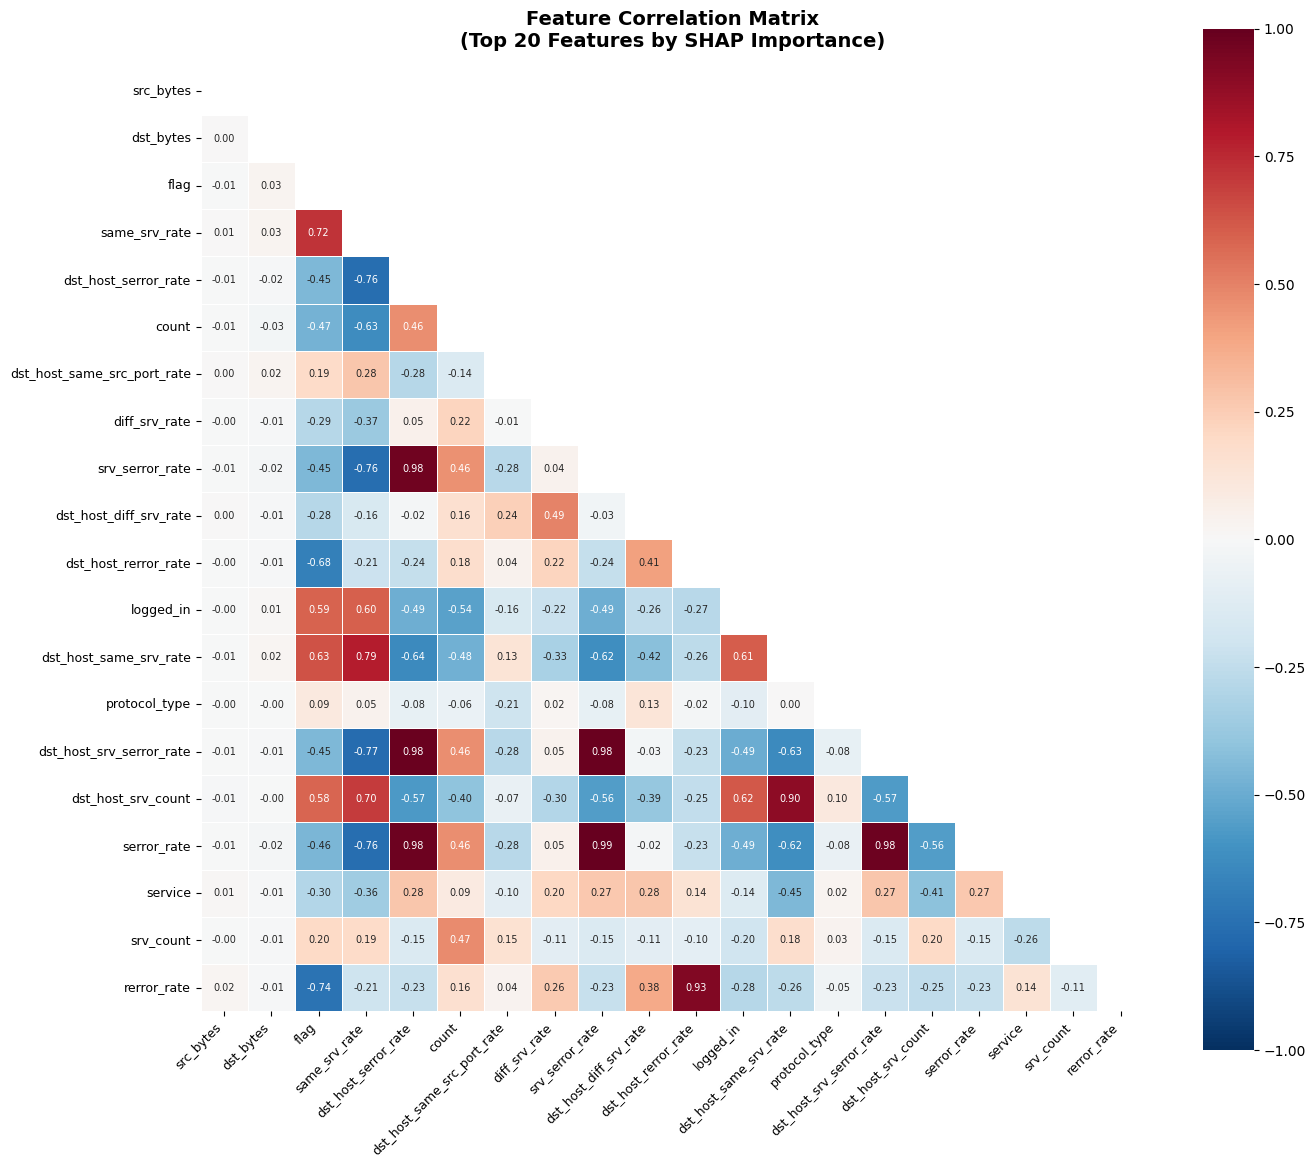

Saved: feature_correlation_heatmap.png

Highly correlated features (|r| > 0.8) may explain why SHAP spreads
importance across multiple related features rather than one alone.


In [ ]:
# Use top 20 features by global SHAP importance for a readable heatmap
mean_per_feature = np.abs(sv).mean(axis=(0, 1))
top20_idx   = np.argsort(mean_per_feature)[::-1][:20]
top20_feats = [feature_cols[i] for i in top20_idx]

corr_matrix = X_train_sc[top20_feats].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # upper triangle mask
sns.heatmap(
    corr_matrix,
    mask   = mask,
    annot  = True,
    fmt    = '.2f',
    cmap   = 'RdBu_r',
    center = 0,
    vmin   = -1, vmax = 1,
    square = True,
    linewidths = 0.5,
    ax     = ax,
    annot_kws = {'size': 7}
)
ax.set_title('Feature Correlation Matrix\n(Top 20 Features by SHAP Importance)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_correlation_heatmap.png')
print('\nHighly correlated features (|r| > 0.8) may explain why SHAP spreads')
print('importance across multiple related features rather than one alone.')

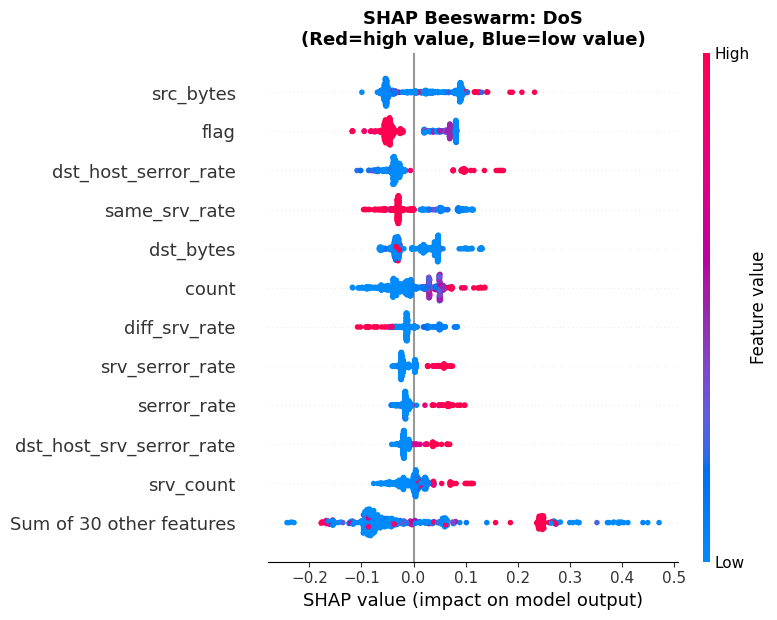

Saved: shap_beeswarm_DoS.png


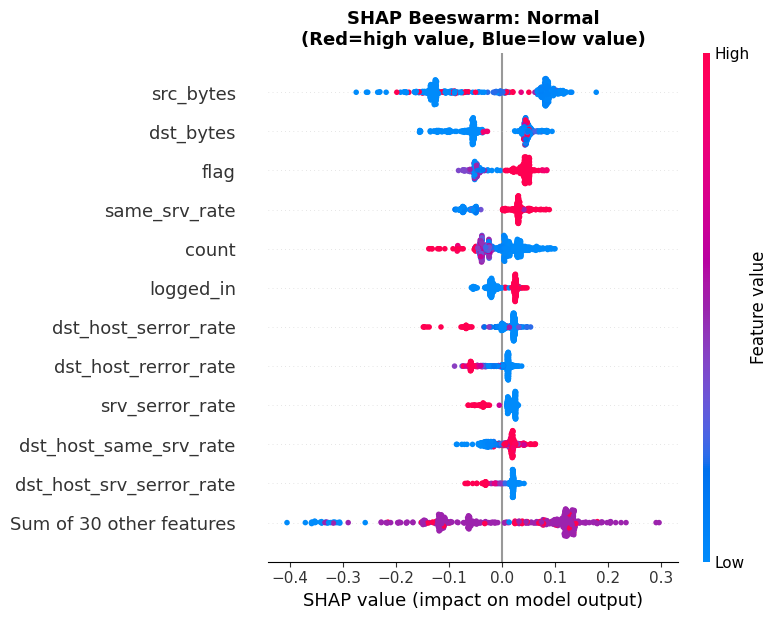

Saved: shap_beeswarm_Normal.png


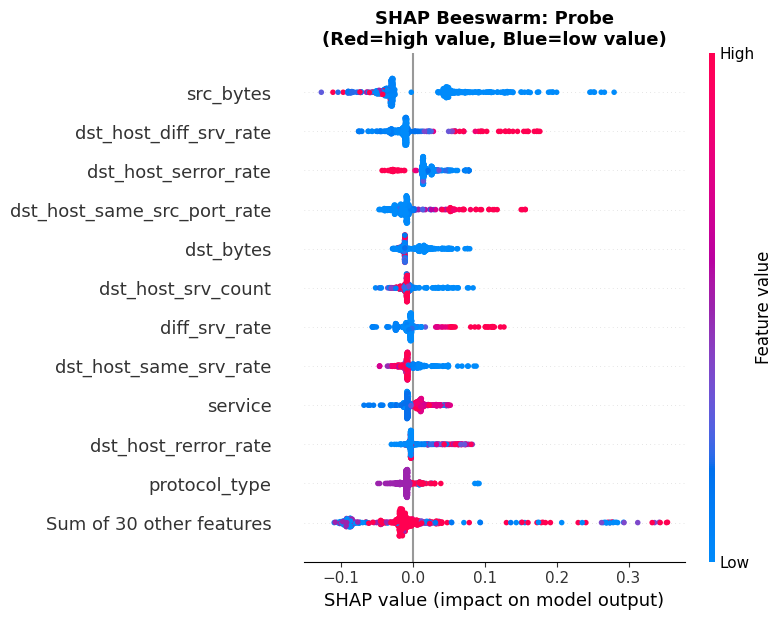

Saved: shap_beeswarm_Probe.png


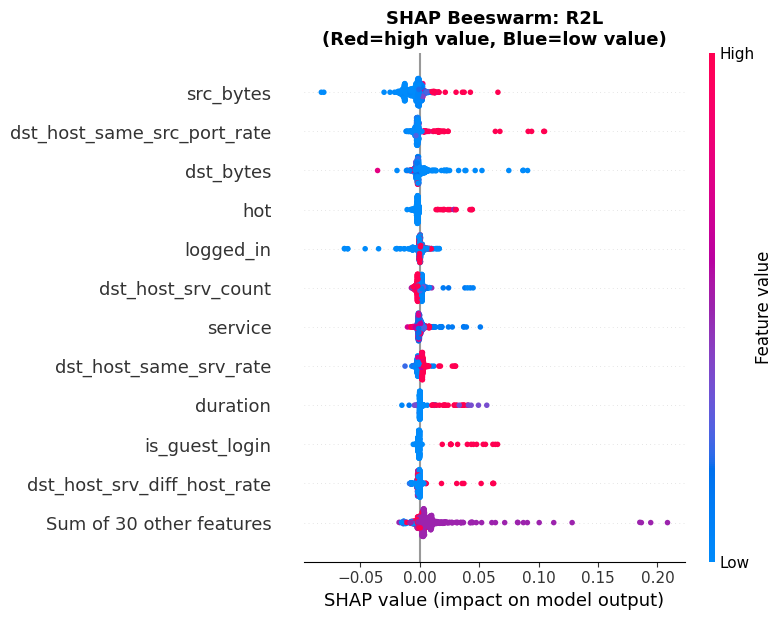

Saved: shap_beeswarm_R2L.png


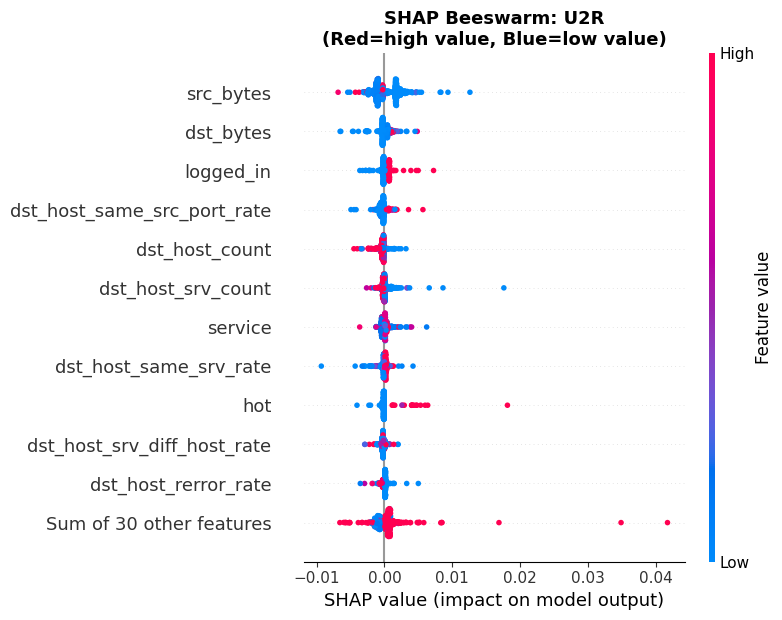

Saved: shap_beeswarm_U2R.png

=== Beeswarm plots complete! ===


In [ ]:
# Beeswarm for each class — shows direction of feature impact
n_shap_classes = sv.shape[0]

for i, cls_name in enumerate(class_names):
    if i >= n_shap_classes:
        continue

    shap_exp_all = shap.Explanation(
        values       = sv[i],              # (n_samples, n_features)
        base_values  = np.full(sv[i].shape[0],
                               explainer.expected_value[i]
                               if hasattr(explainer.expected_value, '__len__')
                               else explainer.expected_value),
        data         = X_sample.values,
        feature_names= feature_cols
    )

    plt.figure(figsize=(10, 7))
    shap.plots.beeswarm(shap_exp_all, max_display=12, show=False)
    plt.title(f'SHAP Beeswarm: {cls_name}\n(Red=high value, Blue=low value)',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = f'shap_beeswarm_{cls_name}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

print('\n=== Beeswarm plots complete! ===')

In [ ]:
import os
import zipfile
from google.colab import files

# ===== SETTINGS =====
output_zip_name = "ml_outputs.zip"
extensions = (".png", ".csv", ".txt", ".json", ".pkl")

# ===== COLLECT FILES =====
files_to_zip = []

for file in os.listdir("."):
    if file.endswith(extensions):
        files_to_zip.append(file)

print("Files found for zipping:")
for f in files_to_zip:
    print(" -", f)

# ===== CREATE ZIP =====
with zipfile.ZipFile(output_zip_name, "w") as zipf:
    for file in files_to_zip:
        zipf.write(file)

print(f"\nCreated zip: {output_zip_name}")

# ===== DOWNLOAD =====
files.download(output_zip_name)

Files found for zipping:
 - shap_beeswarm_DoS.png
 - shap_beeswarm_R2L.png
 - shap_waterfall_R2L.png
 - lime_DoS.png
 - shap_beeswarm_Normal.png
 - feature_correlation_heatmap.png
 - lime_R2L.png
 - confusion_matrices.png
 - shap_beeswarm_U2R.png
 - shap_per_class.png
 - shap_beeswarm_Probe.png
 - lime_Probe.png
 - shap_waterfall_Normal.png
 - lime_Normal.png
 - shap_global_importance.png
 - shap_waterfall_DoS.png
 - shap_vs_lime_DoS.png
 - model_comparison.png
 - shap_waterfall_Probe.png

Created zip: ml_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>